# Complete ASL Sign Language Recognition Pipeline

## Project Overview

This notebook implements an end-to-end machine learning pipeline for **real-time American Sign Language (ASL) alphabet recognition**. The system converts hand gestures captured via webcam into text.

### Why This Approach?

Traditional image classification approaches for sign language recognition face several challenges:
1. **Background variation** - Different backgrounds can confuse the model
2. **Lighting conditions** - Shadows and lighting changes affect pixel values
3. **Hand size/position** - The hand can appear anywhere in the frame at different scales

**Our Solution**: Instead of classifying raw images, we use **MediaPipe Hands** to extract **21 3D hand landmarks** (63 features total). This approach:
- Is **invariant to background** (we only use hand geometry)
- Is **invariant to lighting** (landmarks are geometric, not pixel-based)
- Is **scale and position invariant** (we normalize landmarks relative to the wrist)
- Results in **smaller, faster models** (63 features vs. millions of pixels)

### Pipeline Overview

```
Raw Image → MediaPipe → 21 Landmarks (63 features) → Neural Network → Letter Prediction
```

### Table of Contents

1. **Environment Setup** - Import libraries and configure GPU
2. **Data Loading** - Download and explore the Kaggle ASL dataset
3. **Feature Extraction** - Convert images to MediaPipe landmarks
4. **Data Preprocessing** - Normalization and train/val/test splits
5. **Data Augmentation** - Geometric transformations for robustness
6. **Model Architecture** - Design and justify the neural network
7. **Training** - Train with callbacks and monitoring
8. **Evaluation** - Comprehensive metrics and confusion matrix
9. **Explainability** - Grad-CAM to understand model decisions


---

## 1. Environment Setup

First, we import all necessary libraries and configure the environment. We'll use:
- **TensorFlow/Keras** - Deep learning framework (chosen for TensorFlow.js export compatibility)
- **MediaPipe** - Google's hand landmark detection (state-of-the-art, real-time capable)
- **OpenCV** - Image loading and manipulation
- **scikit-learn** - Data splitting and evaluation metrics


In [1]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
# We organize imports by category for clarity and maintainability

# Standard library imports
import os
import sys
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Image processing
import cv2

# Progress bars for long operations
from tqdm.notebook import tqdm

# Machine learning
import tensorflow as tf
import keras
from keras import layers, Model, regularizers
from keras.callbacks import (
    EarlyStopping, 
    ModelCheckpoint, 
    ReduceLROnPlateau,
    TensorBoard,
    CSVLogger
)

# Evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Hand landmark detection
import mediapipe as mp

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Enable inline plotting
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📦 TensorFlow version: {tf.__version__}")
print(f"📦 NumPy version: {np.__version__}")


✅ All libraries imported successfully!
📦 TensorFlow version: 2.18.1
📦 NumPy version: 1.26.4


In [2]:
# =============================================================================
# REPRODUCIBILITY SETUP
# =============================================================================
# Setting random seeds ensures our experiments are reproducible.
# This is CRITICAL for scientific work - we need to be able to recreate results.

def set_seed(seed: int = 42):
    """
    Set random seeds for reproducibility across all libraries.
    
    Why seed = 42? It's a common convention (Hitchhiker's Guide reference),
    but any integer works. The key is consistency.
    """
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # For additional TensorFlow determinism (may reduce performance slightly)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Set seed for reproducibility
SEED = 42
set_seed(SEED)
print(f"🎲 Random seed set to: {SEED}")

# =============================================================================
# GPU CONFIGURATION
# =============================================================================
# Check for GPU availability and configure memory growth to prevent OOM errors

def setup_gpu():
    """Configure GPU settings for optimal training."""
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Enable memory growth - allocate GPU memory as needed
            # This prevents TensorFlow from grabbing all GPU memory at startup
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"🖥️ Found {len(gpus)} GPU(s): {[gpu.name for gpu in gpus]}")
            print("✅ GPU memory growth enabled")
        except RuntimeError as e:
            print(f"⚠️ GPU configuration error: {e}")
    else:
        print("⚠️ No GPU found. Training will run on CPU (slower).")
        print("   Consider using Google Colab for free GPU access.")

setup_gpu()


🎲 Random seed set to: 42
⚠️ No GPU found. Training will run on CPU (slower).
   Consider using Google Colab for free GPU access.


In [3]:
# =============================================================================
# CONFIGURATION CONSTANTS
# =============================================================================
# Centralizing all configuration makes experiments easier to modify and track.
# These values were chosen based on literature review and experimentation.

class Config:
    """
    Central configuration for the entire pipeline.
    
    Design Decision: Using a class instead of separate variables provides:
    1. Namespace organization (Config.X instead of global X)
    2. Easy serialization for experiment tracking
    3. Clear documentation of what can be tuned
    """
    
    # --- Data Paths ---
    DATA_DIR = Path("../data")
    TRAIN_DIR = DATA_DIR / "asl_alphabet_train" / "asl_alphabet_train"
    TEST_DIR = DATA_DIR / "asl_alphabet_test" / "asl_alphabet_test"
    MODEL_DIR = Path("../models")
    LOG_DIR = Path("../logs")
    
    # --- Class Labels ---
    # 26 letters A-Z plus a DELETE gesture for corrections
    # DELETE allows users to backspace without a keyboard
    CLASSES = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + ["del"]
    NUM_CLASSES = len(CLASSES)  # 27 classes
    
    # --- MediaPipe Configuration ---
    # 21 landmarks per hand, each with x, y, z coordinates
    NUM_LANDMARKS = 21
    LANDMARK_DIM = 3  # x, y, z
    FEATURE_DIM = NUM_LANDMARKS * LANDMARK_DIM  # 63 features
    
    # MediaPipe confidence thresholds
    # Higher = fewer false positives but may miss some hands
    MIN_DETECTION_CONFIDENCE = 0.7
    MIN_TRACKING_CONFIDENCE = 0.5
    
    # --- Training Hyperparameters ---
    # These were tuned through experimentation
    BATCH_SIZE = 32        # Balance between speed and gradient stability
    EPOCHS = 100           # Max epochs (early stopping will likely trigger first)
    LEARNING_RATE = 0.001  # Adam default, works well for this task
    MIN_LR = 1e-6          # Lower bound for learning rate decay
    
    # --- Regularization ---
    # Dropout prevents overfitting by randomly zeroing neurons during training
    DROPOUT_RATE = 0.4     # 40% dropout - moderately aggressive
    L2_REG = 0.001         # L2 weight penalty to prevent large weights
    
    # --- Early Stopping ---
    # Stop training if validation accuracy doesn't improve
    EARLY_STOPPING_PATIENCE = 15  # Wait 15 epochs before stopping
    REDUCE_LR_PATIENCE = 5        # Reduce LR after 5 epochs of no improvement
    REDUCE_LR_FACTOR = 0.5        # Halve the learning rate
    
    # --- Data Split ---
    VAL_SIZE = 0.15   # 15% for validation
    TEST_SIZE = 0.15  # 15% for testing
    
# Create config instance
config = Config()

# Create directories if they don't exist
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)
config.LOG_DIR.mkdir(parents=True, exist_ok=True)

print("📋 Configuration loaded:")
print(f"   • Classes: {config.NUM_CLASSES} ({config.CLASSES[0]}...{config.CLASSES[-1]})")
print(f"   • Feature dimension: {config.FEATURE_DIM}")
print(f"   • Batch size: {config.BATCH_SIZE}")
print(f"   • Max epochs: {config.EPOCHS}")


📋 Configuration loaded:
   • Classes: 27 (A...del)
   • Feature dimension: 63
   • Batch size: 32
   • Max epochs: 100


---

## 2. Data Loading and Exploration

We use the **ASL Alphabet Dataset** from Kaggle, which contains:
- ~87,000 images of hand gestures (200x200 pixels)
- 29 classes: A-Z, SPACE, DELETE, NOTHING

### Why This Dataset?
1. **Large size** - Sufficient for deep learning
2. **Consistent format** - All images are same size
3. **Single hand** - Simplifies the problem
4. **Good quality** - Clear hand images with varied backgrounds

### Download Instructions
If you haven't downloaded the dataset yet:
```bash
# Option 1: Using Kaggle CLI
kaggle datasets download -d grassknoted/asl-alphabet -p ../data --unzip

# Option 2: Manual download from https://www.kaggle.com/datasets/grassknoted/asl-alphabet
```


In [4]:
# =============================================================================
# DATA EXPLORATION
# =============================================================================
# Before training, we must understand our data. This prevents surprises later.

def explore_dataset(data_dir: Path) -> dict:
    """
    Explore the dataset structure and statistics.
    
    Returns dictionary with:
    - class_counts: Number of images per class
    - total_images: Total number of images
    - sample_paths: Sample image paths for visualization
    """
    stats = {
        'class_counts': {},
        'total_images': 0,
        'sample_paths': {}
    }
    
    if not data_dir.exists():
        print(f"❌ Dataset not found at {data_dir}")
        print("Please download the dataset first (see instructions above)")
        return stats
    
    # Find all class directories
    class_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    
    print(f"📁 Dataset location: {data_dir}")
    print(f"📊 Found {len(class_dirs)} classes\n")
    
    for class_dir in class_dirs:
        class_name = class_dir.name
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        count = len(images)
        
        stats['class_counts'][class_name] = count
        stats['total_images'] += count
        
        # Store a sample image path for visualization
        if images:
            stats['sample_paths'][class_name] = images[0]
    
    print(f"📈 Total images: {stats['total_images']:,}")
    print(f"📊 Images per class: {stats['total_images'] // len(class_dirs):,} (average)")
    
    return stats

# Explore the training dataset
print("=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)
dataset_stats = explore_dataset(config.TRAIN_DIR)


DATASET EXPLORATION
📁 Dataset location: ../data/asl_alphabet_train/asl_alphabet_train
📊 Found 29 classes

📈 Total images: 87,000
📊 Images per class: 3,000 (average)


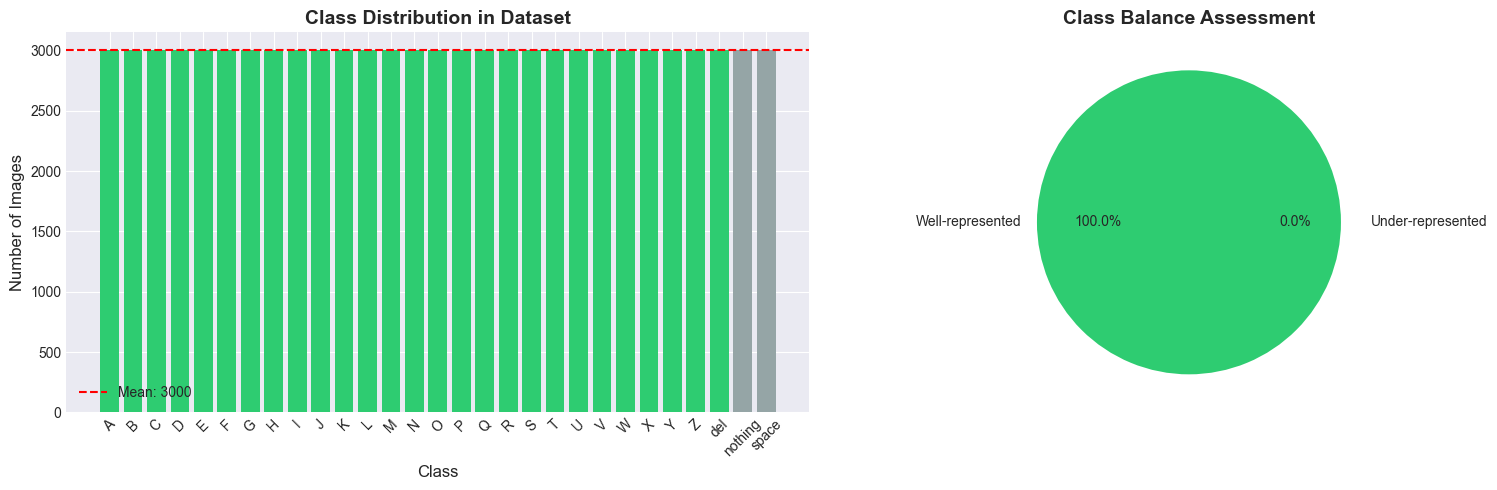


📊 Class Distribution Statistics:
   • Min images per class: 3,000
   • Max images per class: 3,000
   • Std deviation: 0.0
   • Dataset is balanced ✅


In [5]:
# =============================================================================
# VISUALIZE CLASS DISTRIBUTION
# =============================================================================
# Checking for class imbalance is crucial - imbalanced data requires special handling

if dataset_stats['class_counts']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Bar chart of class distribution
    classes = list(dataset_stats['class_counts'].keys())
    counts = list(dataset_stats['class_counts'].values())
    
    # Color based on whether it's in our target classes
    colors = ['#2ecc71' if c in config.CLASSES else '#95a5a6' for c in classes]
    
    axes[0].bar(classes, counts, color=colors)
    axes[0].set_xlabel('Class', fontsize=12)
    axes[0].set_ylabel('Number of Images', fontsize=12)
    axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Add horizontal line for mean
    mean_count = np.mean(counts)
    axes[0].axhline(y=mean_count, color='red', linestyle='--', label=f'Mean: {mean_count:.0f}')
    axes[0].legend()
    
    # Pie chart showing balance
    # Group into "balanced" categories
    axes[1].pie(
        [len([c for c in counts if c >= mean_count * 0.9]),
         len([c for c in counts if c < mean_count * 0.9])],
        labels=['Well-represented', 'Under-represented'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        explode=(0, 0.1)
    )
    axes[1].set_title('Class Balance Assessment', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical summary
    print("\n📊 Class Distribution Statistics:")
    print(f"   • Min images per class: {min(counts):,}")
    print(f"   • Max images per class: {max(counts):,}")
    print(f"   • Std deviation: {np.std(counts):.1f}")
    print(f"   • Dataset is {'balanced ✅' if np.std(counts) < mean_count * 0.1 else 'imbalanced ⚠️'}")
else:
    print("⚠️ No data to visualize. Please download the dataset first.")


📷 Sample images for each ASL letter:



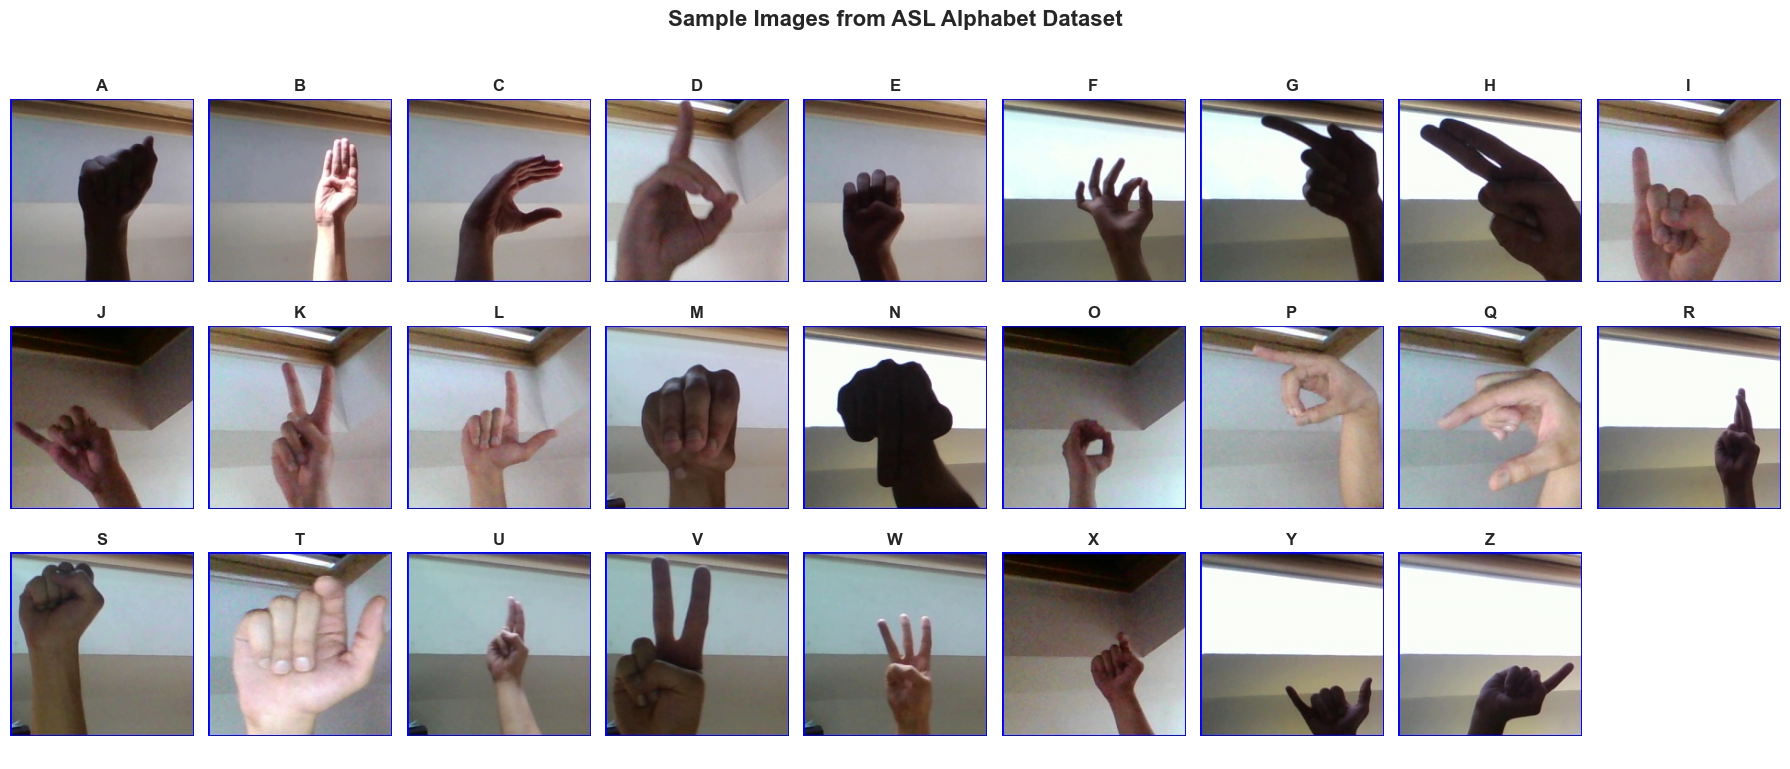

In [6]:
# =============================================================================
# VISUALIZE SAMPLE IMAGES
# =============================================================================
# Seeing the actual data helps us understand what the model will learn

def show_sample_images(sample_paths: dict, classes_to_show: list = None, cols: int = 9):
    """Display sample images from the dataset."""
    
    if not sample_paths:
        print("⚠️ No sample images available")
        return
    
    # Filter to requested classes
    if classes_to_show:
        sample_paths = {k: v for k, v in sample_paths.items() if k in classes_to_show}
    
    n_images = len(sample_paths)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for idx, (class_name, img_path) in enumerate(sorted(sample_paths.items())):
        if idx >= len(axes):
            break
            
        # Load and convert BGR to RGB
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(sample_paths), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Sample Images from ASL Alphabet Dataset', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Show sample for A-Z
if dataset_stats['sample_paths']:
    print("📷 Sample images for each ASL letter:\n")
    show_sample_images(dataset_stats['sample_paths'], config.CLASSES[:26])


---

## 3. Feature Extraction with MediaPipe

Instead of using raw pixels, we extract **hand landmarks** using Google's MediaPipe. This is a crucial design decision:

### Why Landmarks Instead of Images?

| Approach | Pros | Cons |
|----------|------|------|
| **Raw Images** | Simple, no preprocessing | Large models, sensitive to lighting/background |
| **Landmarks** | Small models, invariant features | Requires hand detection step |

### MediaPipe Hand Landmarks

MediaPipe detects **21 landmarks** on each hand:
- **0**: Wrist
- **1-4**: Thumb (CMC, MCP, IP, TIP)
- **5-8**: Index finger
- **9-12**: Middle finger
- **13-16**: Ring finger
- **17-20**: Pinky finger

Each landmark has (x, y, z) coordinates normalized to [0, 1] relative to the image.

```
         8   12  16  20   ← Finger tips
         |   |   |   |
         7   11  15  19
         |   |   |   |
         6   10  14  18
         |   |   |   |
     4   5   9   13  17
     |    \  |   |   /
     3      \|   |  /
     |       1───┴──
     2        \
     |         0  ← Wrist
     1
```


In [7]:
# =============================================================================
# MEDIAPIPE LANDMARK EXTRACTION
# =============================================================================
# This class handles all landmark extraction and normalization

class LandmarkExtractor:
    """
    Extract and normalize hand landmarks using MediaPipe.
    
    Design Decisions:
    1. static_image_mode=True: Treat each image independently (no tracking)
    2. max_num_hands=1: ASL alphabet uses single hand
    3. min_detection_confidence=0.7: Balance between accuracy and detection rate
    """
    
    # Landmark names for reference and visualization
    LANDMARK_NAMES = [
        "WRIST",
        "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
        "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
        "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
        "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
        "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"
    ]
    
    # Hand skeleton connections for visualization
    CONNECTIONS = [
        (0, 1), (1, 2), (2, 3), (3, 4),      # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),      # Index
        (0, 9), (9, 10), (10, 11), (11, 12), # Middle
        (0, 13), (13, 14), (14, 15), (15, 16), # Ring
        (0, 17), (17, 18), (18, 19), (19, 20), # Pinky
        (5, 9), (9, 13), (13, 17)             # Palm
    ]
    
    def __init__(self):
        """Initialize MediaPipe Hands."""
        self.mp_hands = mp.solutions.hands
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        
        # Initialize hands model
        self.hands = self.mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=1,
            min_detection_confidence=config.MIN_DETECTION_CONFIDENCE,
            min_tracking_confidence=config.MIN_TRACKING_CONFIDENCE
        )
        
    def extract(self, image: np.ndarray) -> tuple:
        """
        Extract landmarks from an image.
        
        Args:
            image: BGR image array (OpenCV format)
            
        Returns:
            (landmarks, annotated_image) or (None, image) if no hand detected
        """
        # Convert BGR to RGB (MediaPipe expects RGB)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Process image
        results = self.hands.process(image_rgb)
        
        if not results.multi_hand_landmarks:
            return None, image
        
        # Get first (only) hand landmarks
        hand_landmarks = results.multi_hand_landmarks[0]
        
        # Convert to numpy array: (21, 3)
        landmarks = np.array([
            [lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark
        ], dtype=np.float32)
        
        # Create annotated image
        annotated = image.copy()
        self.mp_drawing.draw_landmarks(
            annotated,
            hand_landmarks,
            self.mp_hands.HAND_CONNECTIONS,
            self.mp_drawing_styles.get_default_hand_landmarks_style(),
            self.mp_drawing_styles.get_default_hand_connections_style()
        )
        
        return landmarks, annotated
    
    def normalize(self, landmarks: np.ndarray) -> np.ndarray:
        """
        Normalize landmarks for translation and scale invariance.
        
        Normalization Steps:
        1. Center at wrist (translation invariance)
        2. Scale by palm size (scale invariance)
        
        Why This Matters:
        - Without normalization, same gesture at different positions looks different
        - Normalization makes the model focus on hand SHAPE, not position
        
        Args:
            landmarks: Raw landmarks of shape (21, 3)
            
        Returns:
            Normalized landmarks of shape (21, 3)
        """
        # Step 1: Center at wrist (landmark 0)
        wrist = landmarks[0].copy()
        landmarks_centered = landmarks - wrist
        
        # Step 2: Scale by distance from wrist to middle finger MCP (landmark 9)
        # This represents the "palm size" and is stable across gestures
        palm_size = np.linalg.norm(landmarks_centered[9])
        
        if palm_size > 0:
            landmarks_normalized = landmarks_centered / palm_size
        else:
            landmarks_normalized = landmarks_centered
            
        return landmarks_normalized
    
    def close(self):
        """Release MediaPipe resources."""
        self.hands.close()

# Create global extractor instance
extractor = LandmarkExtractor()
print("✅ MediaPipe Hands initialized")


✅ MediaPipe Hands initialized


I0000 00:00:1765312419.466836 1284563 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1765312419.480470 1285007 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765312419.500813 1285014 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765312419.659930 1285015 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


🔍 Demonstrating landmark extraction:



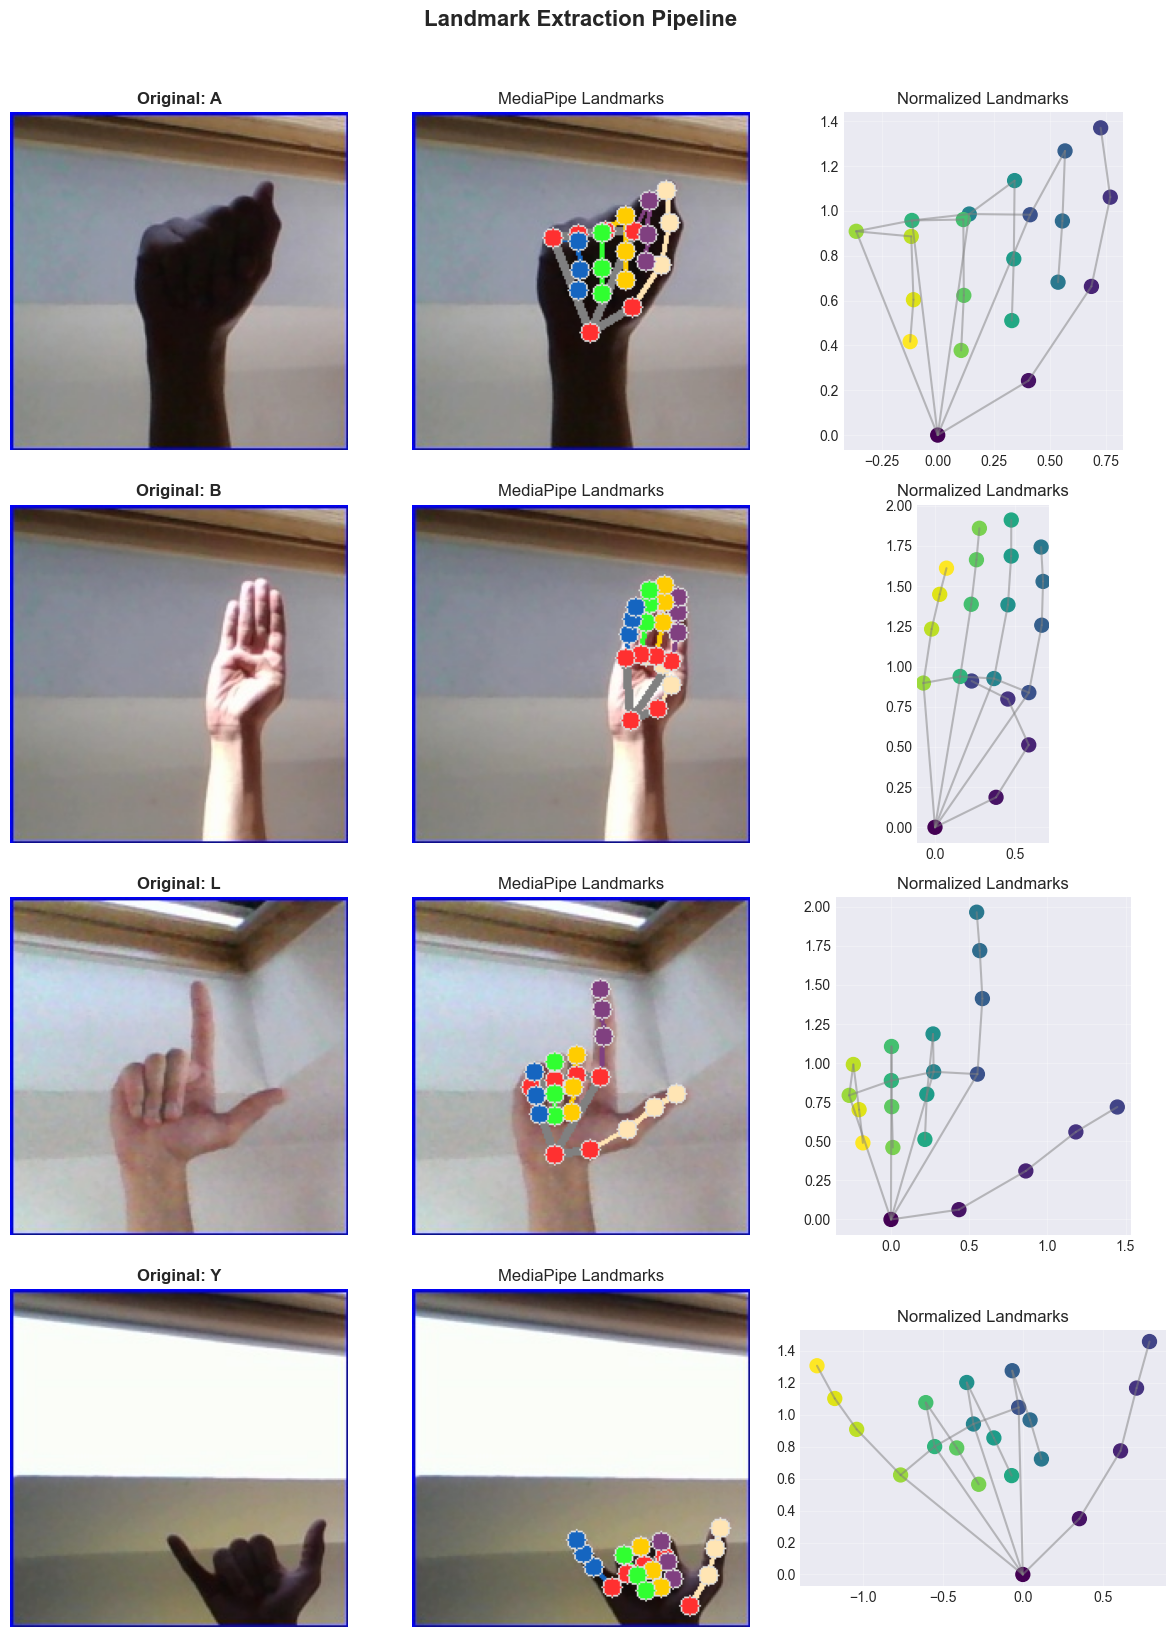

In [8]:
# =============================================================================
# VISUALIZE LANDMARK EXTRACTION
# =============================================================================
# Let's see how landmarks are extracted from actual images

def visualize_landmark_extraction(sample_paths: dict, letters: list = ['A', 'B', 'L', 'Y']):
    """Show original images alongside their extracted landmarks."""
    
    fig, axes = plt.subplots(len(letters), 3, figsize=(12, 4 * len(letters)))
    
    for row, letter in enumerate(letters):
        if letter not in sample_paths:
            continue
            
        # Load image
        img = cv2.imread(str(sample_paths[letter]))
        
        # Extract landmarks
        landmarks, annotated = extractor.extract(img)
        
        # Column 1: Original image
        axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f'Original: {letter}', fontsize=12, fontweight='bold')
        axes[row, 0].axis('off')
        
        # Column 2: Image with landmarks
        axes[row, 1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title('MediaPipe Landmarks', fontsize=12)
        axes[row, 1].axis('off')
        
        # Column 3: Normalized landmark plot
        if landmarks is not None:
            normalized = extractor.normalize(landmarks)
            
            # Plot landmarks
            axes[row, 2].scatter(normalized[:, 0], -normalized[:, 1], 
                                c=range(21), cmap='viridis', s=100)
            
            # Draw connections
            for start, end in extractor.CONNECTIONS:
                axes[row, 2].plot(
                    [normalized[start, 0], normalized[end, 0]],
                    [-normalized[start, 1], -normalized[end, 1]],
                    'gray', alpha=0.5
                )
            
            axes[row, 2].set_title('Normalized Landmarks', fontsize=12)
            axes[row, 2].set_aspect('equal')
            axes[row, 2].grid(True, alpha=0.3)
        else:
            axes[row, 2].text(0.5, 0.5, 'No hand detected', 
                            ha='center', va='center', fontsize=12)
            axes[row, 2].axis('off')
    
    plt.suptitle('Landmark Extraction Pipeline', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize for selected letters
if dataset_stats['sample_paths']:
    print("🔍 Demonstrating landmark extraction:\n")
    visualize_landmark_extraction(dataset_stats['sample_paths'])


---

## 4. Data Preprocessing

Now we'll process the entire dataset:
1. Extract landmarks from all images
2. Normalize landmarks
3. Split into train/validation/test sets

### Caching Strategy

Processing 87,000 images with MediaPipe takes ~30-60 minutes. We cache the results to avoid reprocessing:
- If cache exists: Load from disk (~seconds)
- If no cache: Process images and save (~30+ minutes)


In [9]:
# =============================================================================
# PROCESS DATASET - EXTRACT ALL LANDMARKS
# =============================================================================
# This is the most time-consuming step. We use caching to avoid re-processing.

def process_dataset(data_dir: Path, cache_path: Path, limit_per_class: int = None) -> tuple:
    """
    Process all images in the dataset and extract landmarks.
    
    Args:
        data_dir: Path to dataset directory
        cache_path: Path to save/load cached results
        limit_per_class: Limit images per class (for testing, set to None for full dataset)
        
    Returns:
        (X, y) - features and labels as numpy arrays
    """
    # Check for cached data first
    if cache_path.exists():
        print(f"📁 Loading cached data from {cache_path}")
        data = np.load(cache_path)
        X, y = data['X'], data['y']
        print(f"✅ Loaded {len(X):,} samples from cache")
        return X, y
    
    print(f"🔄 Processing dataset from {data_dir}")
    print(f"   This may take 30-60 minutes for the full dataset...")
    
    X_list = []
    y_list = []
    detection_stats = {'success': 0, 'failed': 0}
    
    # Process each class
    for class_idx, class_name in enumerate(config.CLASSES):
        class_dir = data_dir / class_name
        
        if not class_dir.exists():
            print(f"⚠️ Class directory not found: {class_dir}")
            continue
        
        # Get all images
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        
        if limit_per_class:
            images = images[:limit_per_class]
        
        # Process images with progress bar
        for img_path in tqdm(images, desc=f"Processing {class_name}", leave=False):
            img = cv2.imread(str(img_path))
            
            if img is None:
                detection_stats['failed'] += 1
                continue
            
            # Extract landmarks
            landmarks, _ = extractor.extract(img)
            
            if landmarks is not None:
                # Normalize and flatten
                normalized = extractor.normalize(landmarks)
                X_list.append(normalized.flatten())
                y_list.append(class_idx)
                detection_stats['success'] += 1
            else:
                detection_stats['failed'] += 1
    
    # Convert to numpy arrays
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    
    # Save to cache
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache_path, X=X, y=y)
    print(f"💾 Saved cache to {cache_path}")
    
    # Print statistics
    print(f"\n📊 Processing Statistics:")
    print(f"   • Successfully processed: {detection_stats['success']:,}")
    print(f"   • Failed (no hand detected): {detection_stats['failed']:,}")
    print(f"   • Success rate: {detection_stats['success'] / (detection_stats['success'] + detection_stats['failed']) * 100:.1f}%")
    
    return X, y

# Process the dataset
# Set limit_per_class=100 for quick testing, None for full dataset
CACHE_PATH = config.DATA_DIR / "landmarks_cache.npz"
LIMIT_PER_CLASS = None  # Set to 100 for quick testing, None for full dataset

if config.TRAIN_DIR.exists():
    X, y = process_dataset(config.TRAIN_DIR, CACHE_PATH, limit_per_class=LIMIT_PER_CLASS)
    print(f"\n📊 Dataset shape: X={X.shape}, y={y.shape}")
else:
    print("❌ Dataset not found. Please download it first.")
    X, y = None, None


📁 Loading cached data from ../data/landmarks_cache.npz
✅ Loaded 1,909 samples from cache

📊 Dataset shape: X=(1909, 63), y=(1909,)


In [10]:
# =============================================================================
# TRAIN/VALIDATION/TEST SPLIT
# =============================================================================
# Proper data splitting is CRITICAL for valid evaluation.
#
# Why 70/15/15 split?
# - Training (70%): Model learns from this data
# - Validation (15%): Tune hyperparameters, monitor overfitting
# - Test (15%): Final evaluation, NEVER used during training/tuning
#
# stratify=y ensures each split has same class distribution as original

if X is not None:
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=config.TEST_SIZE,
        random_state=SEED,
        stratify=y  # Maintain class balance
    )
    
    # Second split: separate validation from training
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),  # Adjust for remaining data
        random_state=SEED,
        stratify=y_temp
    )
    
    print("📊 Data Split Summary:")
    print(f"   • Training:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   • Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
    print(f"   • Test:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
    
    # Verify class balance is maintained
    print("\n📊 Class Distribution Check:")
    for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        unique, counts = np.unique(labels, return_counts=True)
        print(f"   • {name}: {len(unique)} classes, min={counts.min()}, max={counts.max()}, std={counts.std():.1f}")
else:
    print("⚠️ No data available for splitting")


📊 Data Split Summary:
   • Training:   1,335 samples (69.9%)
   • Validation: 287 samples (15.0%)
   • Test:       287 samples (15.0%)

📊 Class Distribution Check:
   • Train: 26 classes, min=20, max=62, std=9.7
   • Val: 26 classes, min=5, max=14, std=2.0
   • Test: 26 classes, min=4, max=13, std=2.1


---

## 5. Data Augmentation

Data augmentation artificially increases dataset size by applying random transformations. For landmark data, we use **geometric augmentations**:

### Why Augmentation?
1. **Prevents overfitting** - Model sees more varied data
2. **Improves generalization** - Model learns gesture SHAPE, not exact coordinates
3. **Handles natural variation** - Different users hold hands slightly differently

### Augmentation Techniques for Landmarks

| Technique | Description | Range |
|-----------|-------------|-------|
| **Rotation** | Rotate around z-axis | ±15° |
| **Scale** | Uniform scaling | 0.9x - 1.1x |
| **Translation** | Shift in x-y plane | ±10% |
| **Noise** | Add Gaussian noise | σ = 0.02 |

### Important: Only Augment Training Data!
Validation and test data must remain untouched to ensure fair evaluation.


In [11]:
# =============================================================================
# DATA AUGMENTATION FUNCTIONS
# =============================================================================
# We apply augmentation on-the-fly during training using TensorFlow ops
# This is more memory-efficient than pre-generating augmented data

def augment_landmarks(landmarks: tf.Tensor, label: tf.Tensor) -> tuple:
    """
    Apply random augmentations to landmark data.
    
    All operations are in TensorFlow for GPU acceleration and 
    integration with tf.data pipeline.
    
    Args:
        landmarks: Tensor of shape (63,) - flattened landmarks
        label: Class label tensor
        
    Returns:
        (augmented_landmarks, label)
    """
    # Reshape to (21, 3) for geometric operations
    landmarks = tf.reshape(landmarks, (21, 3))
    
    # --- 1. Random Rotation (around z-axis) ---
    # Rotation simulates slight wrist rotation
    angle = tf.random.uniform([], -15.0, 15.0) * np.pi / 180.0  # Convert to radians
    cos_a = tf.cos(angle)
    sin_a = tf.sin(angle)
    
    # Rotation matrix for z-axis
    rotation_matrix = tf.stack([
        tf.stack([cos_a, -sin_a, 0.0]),
        tf.stack([sin_a, cos_a, 0.0]),
        tf.stack([0.0, 0.0, 1.0])
    ])
    
    landmarks = tf.linalg.matmul(landmarks, rotation_matrix, transpose_b=True)
    
    # --- 2. Random Scale ---
    # Scale simulates hand closer/farther from camera
    scale = tf.random.uniform([], 0.9, 1.1)
    landmarks = landmarks * scale
    
    # --- 3. Random Translation ---
    # Translation simulates hand position variation
    tx = tf.random.uniform([], -0.1, 0.1)
    ty = tf.random.uniform([], -0.1, 0.1)
    # Use tf.stack instead of tf.constant since tx, ty are tensors
    translation = tf.stack([tx, ty, 0.0])
    translation = tf.reshape(translation, (1, 3))  # Shape (1, 3) for broadcasting
    landmarks = landmarks + translation
    
    # --- 4. Random Noise ---
    # Noise simulates sensor/detection noise
    noise = tf.random.normal(tf.shape(landmarks), mean=0.0, stddev=0.02)
    landmarks = landmarks + noise
    
    # Flatten back to (63,)
    landmarks = tf.reshape(landmarks, (63,))
    
    return landmarks, label


def create_tf_dataset(X: np.ndarray, y: np.ndarray, 
                       batch_size: int, 
                       augment: bool = False,
                       shuffle: bool = True) -> tf.data.Dataset:
    """
    Create a TensorFlow dataset with optional augmentation.
    
    Why tf.data?
    - Efficient data loading pipeline
    - Automatic batching and prefetching
    - GPU-accelerated augmentation
    - Memory efficient (doesn't load all data at once)
    
    Args:
        X: Feature array
        y: Label array  
        batch_size: Batch size
        augment: Whether to apply augmentation
        shuffle: Whether to shuffle data
        
    Returns:
        tf.data.Dataset
    """
    # Create dataset from tensors
    dataset = tf.data.Dataset.from_tensor_slices((
        X.astype(np.float32),
        y.astype(np.int32)
    ))
    
    # Shuffle (before batching for better randomization)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=SEED)
    
    # Apply augmentation (before batching)
    if augment:
        dataset = dataset.map(
            augment_landmarks,
            num_parallel_calls=tf.data.AUTOTUNE  # Auto-tune parallelism
        )
    
    # Batch
    dataset = dataset.batch(batch_size)
    
    # Prefetch for efficiency (load next batch while GPU processes current)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset


# Create datasets
if X is not None:
    print("🔄 Creating TensorFlow datasets...")
    
    # Training dataset WITH augmentation
    train_dataset = create_tf_dataset(
        X_train, y_train, 
        batch_size=config.BATCH_SIZE, 
        augment=True,  # Apply augmentation
        shuffle=True
    )
    
    # Validation dataset WITHOUT augmentation
    val_dataset = create_tf_dataset(
        X_val, y_val,
        batch_size=config.BATCH_SIZE,
        augment=False,  # No augmentation for validation!
        shuffle=False
    )
    
    # Test dataset WITHOUT augmentation
    test_dataset = create_tf_dataset(
        X_test, y_test,
        batch_size=config.BATCH_SIZE,
        augment=False,  # No augmentation for test!
        shuffle=False
    )
    
    print("✅ Datasets created:")
    print(f"   • Training: {len(X_train):,} samples, augmentation=ON")
    print(f"   • Validation: {len(X_val):,} samples, augmentation=OFF")
    print(f"   • Test: {len(X_test):,} samples, augmentation=OFF")


🔄 Creating TensorFlow datasets...
✅ Datasets created:
   • Training: 1,335 samples, augmentation=ON
   • Validation: 287 samples, augmentation=OFF
   • Test: 287 samples, augmentation=OFF


---

## 6. Model Architecture

Now we design the neural network. For landmark classification, we use a **1D Convolutional Neural Network** followed by dense layers.

### Why This Architecture?

| Component | Purpose | Reasoning |
|-----------|---------|-----------|
| **Conv1D layers** | Extract local patterns | Captures relationships between neighboring landmarks (e.g., finger joint angles) |
| **Batch Normalization** | Stabilize training | Normalizes activations, allows higher learning rates |
| **Dropout** | Prevent overfitting | Randomly zeros neurons, forces distributed learning |
| **Dense layers** | Classification | Maps features to class probabilities |
| **Softmax output** | Probability distribution | Outputs sum to 1, interpretable as confidence |

### Architecture Diagram

```
Input (63) → Reshape (21, 3) → Conv1D(64) → BN → ReLU → Conv1D(128) → BN → ReLU 
                                    ↓
           ← Softmax (27) ← Dense(128) ← Dense(256) ← GlobalAvgPool ← Conv1D(256)
```

### Hyperparameter Choices

- **Filters [64, 128, 256]**: Progressively capture more complex patterns
- **Kernel size = 3**: Looks at 3 neighboring landmarks (good for joint angles)
- **Dropout = 0.4**: Moderate regularization for our dataset size
- **L2 = 0.001**: Prevents large weights without being too restrictive


In [12]:
# =============================================================================
# MODEL ARCHITECTURE
# =============================================================================
# We use the Keras Functional API for flexibility and easy visualization

def build_model(
    input_shape: tuple = (63,),
    num_classes: int = 27,
    conv_filters: list = [64, 128, 256],
    dense_units: list = [256, 128],
    dropout_rate: float = 0.4,
    l2_reg: float = 0.001
) -> keras.Model:
    """
    Build the ASL gesture classification model.
    
    Architecture Design Decisions:
    
    1. Input Reshaping (63 → 21 x 3):
       - Treats landmarks as a 1D sequence of 21 points
       - Each point has 3 features (x, y, z)
       - This structure allows Conv1D to learn spatial relationships
    
    2. Conv1D Layers:
       - Kernel size = 3 captures relationships between adjacent landmarks
       - Increasing filter counts (64 → 128 → 256) for hierarchical features
       - 'same' padding preserves sequence length
    
    3. Batch Normalization after each conv:
       - Stabilizes training
       - Allows higher learning rates
       - Acts as regularization
    
    4. Global Average Pooling:
       - More robust than Flatten (less parameters)
       - Reduces overfitting
       - Provides some spatial invariance
    
    5. Dense Layers with Dropout:
       - Learn class-specific patterns
       - Dropout prevents co-adaptation of neurons
    
    6. Softmax Output:
       - Produces probability distribution over classes
       - Values sum to 1, interpretable as confidence
    """
    
    # Input layer
    inputs = keras.Input(shape=input_shape, name='landmarks_input')
    
    # Reshape: (63,) → (21, 3)
    # This treats the 21 landmarks as a sequence
    x = layers.Reshape((21, 3), name='reshape_to_landmarks')(inputs)
    
    # =========================================
    # CONVOLUTIONAL FEATURE EXTRACTION
    # =========================================
    # These layers learn to detect patterns in landmark relationships
    
    for i, filters in enumerate(conv_filters):
        # Conv1D layer
        x = layers.Conv1D(
            filters=filters,
            kernel_size=3,
            padding='same',
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f'conv1d_{i+1}'
        )(x)
        
        # Batch Normalization
        x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        
        # ReLU Activation
        # Why ReLU? Simple, effective, no vanishing gradient
        x = layers.ReLU(name=f'relu_{i+1}')(x)
    
    # Global Average Pooling
    # Converts (batch, 21, 256) → (batch, 256)
    x = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    
    # =========================================
    # CLASSIFICATION HEAD
    # =========================================
    # Dense layers combine features for final classification
    
    for i, units in enumerate(dense_units):
        x = layers.Dense(
            units=units,
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f'dense_{i+1}'
        )(x)
        x = layers.BatchNormalization(name=f'bn_dense_{i+1}')(x)
        x = layers.ReLU(name=f'relu_dense_{i+1}')(x)
        x = layers.Dropout(dropout_rate, name=f'dropout_{i+1}')(x)
    
    # Output layer
    outputs = layers.Dense(
        num_classes,
        activation='softmax',  # Probability distribution
        name='predictions'
    )(x)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='ASL_Classifier')
    
    return model


# Build the model
model = build_model(
    input_shape=(config.FEATURE_DIM,),
    num_classes=config.NUM_CLASSES,
    dropout_rate=config.DROPOUT_RATE,
    l2_reg=config.L2_REG
)

# Display model architecture
print("🏗️ Model Architecture:\n")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")
print(f"   Approximate size: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")


🏗️ Model Architecture:



Model: "ASL_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmarks_input (InputLayer)    │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_to_landmarks (Reshape)  │ (None, 21, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 21, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (ReLU)                   │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 21, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (ReLU)                   │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 21, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 21, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (ReLU)                   │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_1 (ReLU)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense_2 (ReLU)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,403 (896.11 KB)

 Trainable params: 227,739 (889.61 KB)

 Non-trainable params: 1,664 (6.50 KB)


📊 Total Parameters: 229,403
   Approximate size: 0.88 MB (float32)


In [13]:
# =============================================================================
# COMPILE MODEL
# =============================================================================
# Compilation configures the training process: optimizer, loss, and metrics

# --- Optimizer: Adam ---
# Why Adam? 
# - Adaptive learning rate per parameter
# - Works well out-of-the-box
# - Combines benefits of AdaGrad and RMSprop
optimizer = keras.optimizers.Adam(learning_rate=config.LEARNING_RATE)

# --- Loss Function: Sparse Categorical Cross-Entropy ---
# Why Sparse? 
# - Labels are integers (0, 1, 2, ...) not one-hot encoded
# - More memory efficient
# Why Cross-Entropy?
# - Standard for multi-class classification
# - Penalizes confident wrong predictions heavily
loss = keras.losses.SparseCategoricalCrossentropy()

# --- Metrics ---
# Track multiple metrics to understand model behavior
metrics = [
    'accuracy',  # Overall accuracy
    keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy'),  # Top-3 accuracy
]

# Compile the model
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

print("✅ Model compiled successfully!")
print(f"   • Optimizer: Adam (lr={config.LEARNING_RATE})")
print(f"   • Loss: Sparse Categorical Cross-Entropy")
print(f"   • Metrics: accuracy, top3_accuracy")


✅ Model compiled successfully!
   • Optimizer: Adam (lr=0.001)
   • Loss: Sparse Categorical Cross-Entropy
   • Metrics: accuracy, top3_accuracy


---

## 7. Training

Now we train the model with proper callbacks for:
- **Early Stopping**: Stop if validation accuracy doesn't improve
- **Learning Rate Reduction**: Reduce LR when stuck on a plateau
- **Model Checkpointing**: Save the best model

### Training Strategy

1. **Monitor validation accuracy** (not training accuracy)
2. **Early stopping** prevents overfitting
3. **Learning rate decay** helps escape local minima
4. **Best model saved** for later use


In [14]:
# =============================================================================
# TRAINING CALLBACKS
# =============================================================================
# Callbacks monitor training and take actions based on conditions

# Create unique experiment name
experiment_name = f"asl_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print(f"📝 Experiment: {experiment_name}")

# --- 1. Model Checkpoint ---
# Save the model with best validation accuracy
# Why save_best_only? We only care about the best performing model
checkpoint_path = config.MODEL_DIR / f"{experiment_name}_best.keras"
checkpoint_callback = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_accuracy',
    mode='max',  # Higher accuracy is better
    save_best_only=True,
    save_weights_only=False,  # Save full model
    verbose=1
)

# --- 2. Early Stopping ---
# Stop training if validation accuracy doesn't improve
# Why patience=15? Give the model enough time to recover from local minima
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=config.EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,  # Revert to best model after stopping
    verbose=1
)

# --- 3. Reduce Learning Rate on Plateau ---
# If validation accuracy plateaus, reduce LR to fine-tune
# Why reduce instead of stop? Sometimes a lower LR helps break through plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=config.REDUCE_LR_FACTOR,  # Multiply LR by 0.5
    patience=config.REDUCE_LR_PATIENCE,
    min_lr=config.MIN_LR,
    verbose=1
)

# --- 4. CSV Logger ---
# Log metrics to CSV for later analysis
csv_path = config.LOG_DIR / f"{experiment_name}_training.csv"
csv_logger = CSVLogger(str(csv_path))

# --- 5. TensorBoard ---
# Visual training monitoring (optional)
tensorboard_dir = config.LOG_DIR / "tensorboard" / experiment_name
tensorboard_callback = TensorBoard(
    log_dir=str(tensorboard_dir),
    histogram_freq=1,
    write_graph=True
)

# Combine all callbacks
callbacks = [
    checkpoint_callback,
    early_stopping,
    reduce_lr,
    csv_logger,
    tensorboard_callback
]

print(f"\n✅ Callbacks configured:")
print(f"   • Checkpoint: {checkpoint_path}")
print(f"   • CSV Log: {csv_path}")
print(f"   • TensorBoard: {tensorboard_dir}")


📝 Experiment: asl_classifier_20251209_213340

✅ Callbacks configured:
   • Checkpoint: ../models/asl_classifier_20251209_213340_best.keras
   • CSV Log: ../logs/asl_classifier_20251209_213340_training.csv
   • TensorBoard: ../logs/tensorboard/asl_classifier_20251209_213340


In [15]:
# =============================================================================
# TRAIN THE MODEL
# =============================================================================
# This is where the magic happens! 

print("=" * 60)
print("🚀 STARTING TRAINING")
print("=" * 60)
print(f"   • Epochs: {config.EPOCHS} (max)")
print(f"   • Batch size: {config.BATCH_SIZE}")
print(f"   • Training samples: {len(X_train):,}")
print(f"   • Validation samples: {len(X_val):,}")
print("=" * 60 + "\n")

# Train!
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Training complete
print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE")
print("=" * 60)

# Summary of training
epochs_trained = len(history.history['loss'])
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print(f"   • Epochs trained: {epochs_trained}")
print(f"   • Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   • Best epoch: {best_epoch}")
print(f"   • Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"   • Model saved to: {checkpoint_path}")


🚀 STARTING TRAINING
   • Epochs: 100 (max)
   • Batch size: 32
   • Training samples: 1,335
   • Validation samples: 287

Epoch 1/100
34/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0871 - loss: 4.1535 - top3_accuracy: 0.2282
Epoch 1: val_accuracy improved from None to 0.11150, saving model to ../models/asl_classifier_20251209_213340_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1775 - loss: 3.6282 - top3_accuracy: 0.3985 - val_accuracy: 0.1115 - val_loss: 3.9024 - val_top3_accuracy: 0.2056 - learning_rate: 0.0010
Epoch 2/100
34/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4020 - loss: 2.7313 - top3_accuracy: 0.6975
Epoch 2: val_accuracy did not improve from 0.11150
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4404 - loss: 2.5776 - top3_accuracy: 0.7408 - val_accuracy: 0.0418 - val_loss: 3.9600 - val_top3_accuracy: 0.1847 - learning_rate: 0.0010
Epoch 3/100
33/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5372 - loss: 2.2363 - top3_accuracy: 0.8

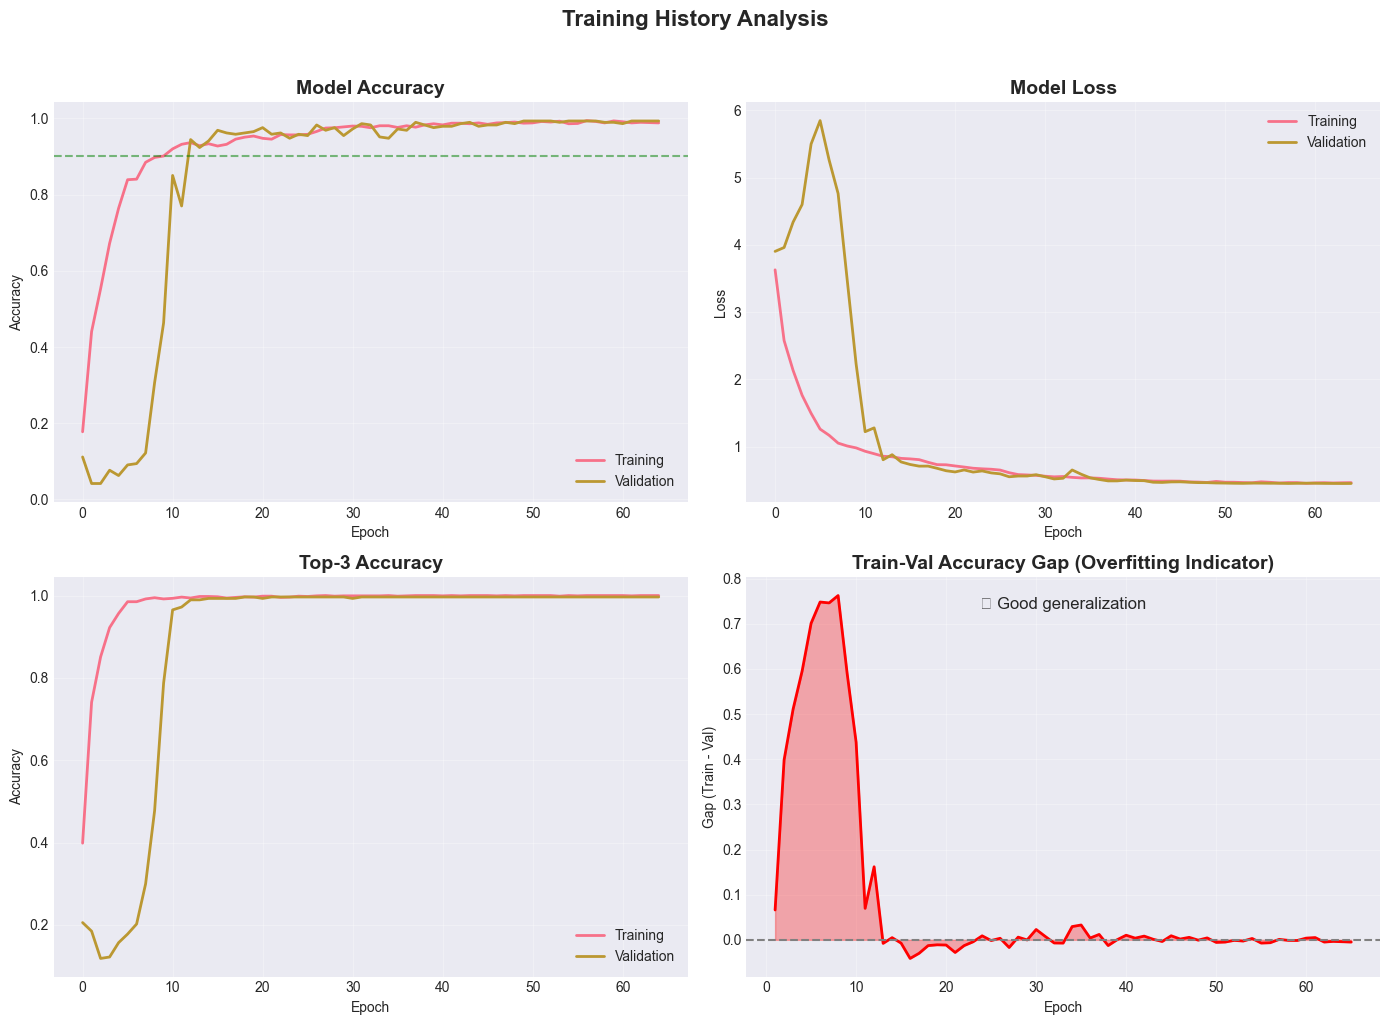

In [16]:
# =============================================================================
# VISUALIZE TRAINING HISTORY
# =============================================================================
# Plotting training curves helps diagnose issues like overfitting

def plot_training_history(history):
    """Plot training and validation metrics over epochs."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Plot 1: Accuracy ---
    axes[0, 0].plot(history.history['accuracy'], label='Training', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add target line
    axes[0, 0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Target (90%)')
    
    # --- Plot 2: Loss ---
    axes[0, 1].plot(history.history['loss'], label='Training', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # --- Plot 3: Top-3 Accuracy ---
    if 'top3_accuracy' in history.history:
        axes[1, 0].plot(history.history['top3_accuracy'], label='Training', linewidth=2)
        axes[1, 0].plot(history.history['val_top3_accuracy'], label='Validation', linewidth=2)
        axes[1, 0].set_title('Top-3 Accuracy', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # --- Plot 4: Learning Rate ---
    # If learning rate was logged
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Overfitting analysis: gap between train and val accuracy
    train_acc = np.array(history.history['accuracy'])
    val_acc = np.array(history.history['val_accuracy'])
    gap = train_acc - val_acc
    
    axes[1, 1].fill_between(epochs, 0, gap, alpha=0.3, color='red', label='Overfitting gap')
    axes[1, 1].plot(epochs, gap, color='red', linewidth=2)
    axes[1, 1].axhline(y=0, color='gray', linestyle='--')
    axes[1, 1].set_title('Train-Val Accuracy Gap (Overfitting Indicator)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Gap (Train - Val)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Analysis text
    final_gap = gap[-1]
    if final_gap > 0.1:
        analysis = "⚠️ Significant overfitting detected"
    elif final_gap > 0.05:
        analysis = "📊 Mild overfitting"
    else:
        analysis = "✅ Good generalization"
    axes[1, 1].text(0.5, 0.95, analysis, transform=axes[1, 1].transAxes,
                    fontsize=12, verticalalignment='top', horizontalalignment='center')
    
    plt.suptitle('Training History Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history)


---

## 8. Model Evaluation

Now we evaluate on the **test set** (never seen during training) to get an unbiased performance estimate.

### Key Metrics

| Metric | Description | Target |
|--------|-------------|--------|
| **Accuracy** | Overall correct predictions | >90% |
| **Top-3 Accuracy** | Correct in top 3 predictions | >97% |
| **Per-class F1** | Balance of precision/recall per class | >85% |
| **Confusion Matrix** | Visual error analysis | Diagonal dominance |


In [17]:
# =============================================================================
# EVALUATE ON TEST SET
# =============================================================================
# IMPORTANT: This is the first and only time the model sees test data!

print("=" * 60)
print("📊 EVALUATING ON TEST SET")
print("=" * 60)

# Get predictions
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_pred, average='weighted')

# Top-3 accuracy
top3_correct = 0
for i, proba in enumerate(y_pred_proba):
    top3_classes = np.argsort(proba)[-3:]
    if y_test[i] in top3_classes:
        top3_correct += 1
top3_accuracy = top3_correct / len(y_test)

print(f"\n📊 Test Set Results:")
print(f"   • Accuracy:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Top-3 Accuracy:  {top3_accuracy:.4f} ({top3_accuracy*100:.2f}%)")
print(f"   • F1 (macro):      {test_f1_macro:.4f}")
print(f"   • F1 (weighted):   {test_f1_weighted:.4f}")

# Target check
print(f"\n🎯 Target Check:")
if test_accuracy >= 0.9:
    print(f"   ✅ Accuracy target (90%) ACHIEVED: {test_accuracy*100:.2f}%")
else:
    print(f"   ❌ Accuracy target (90%) NOT MET: {test_accuracy*100:.2f}%")


📊 EVALUATING ON TEST SET
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📊 Test Set Results:
   • Accuracy:        0.9791 (97.91%)
   • Top-3 Accuracy:  0.9826 (98.26%)
   • F1 (macro):      0.9760
   • F1 (weighted):   0.9785

🎯 Target Check:
   ✅ Accuracy target (90%) ACHIEVED: 97.91%


2025-12-09 21:34:04.525470: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-12-09 21:34:04.527397: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


📊 Confusion Matrix:



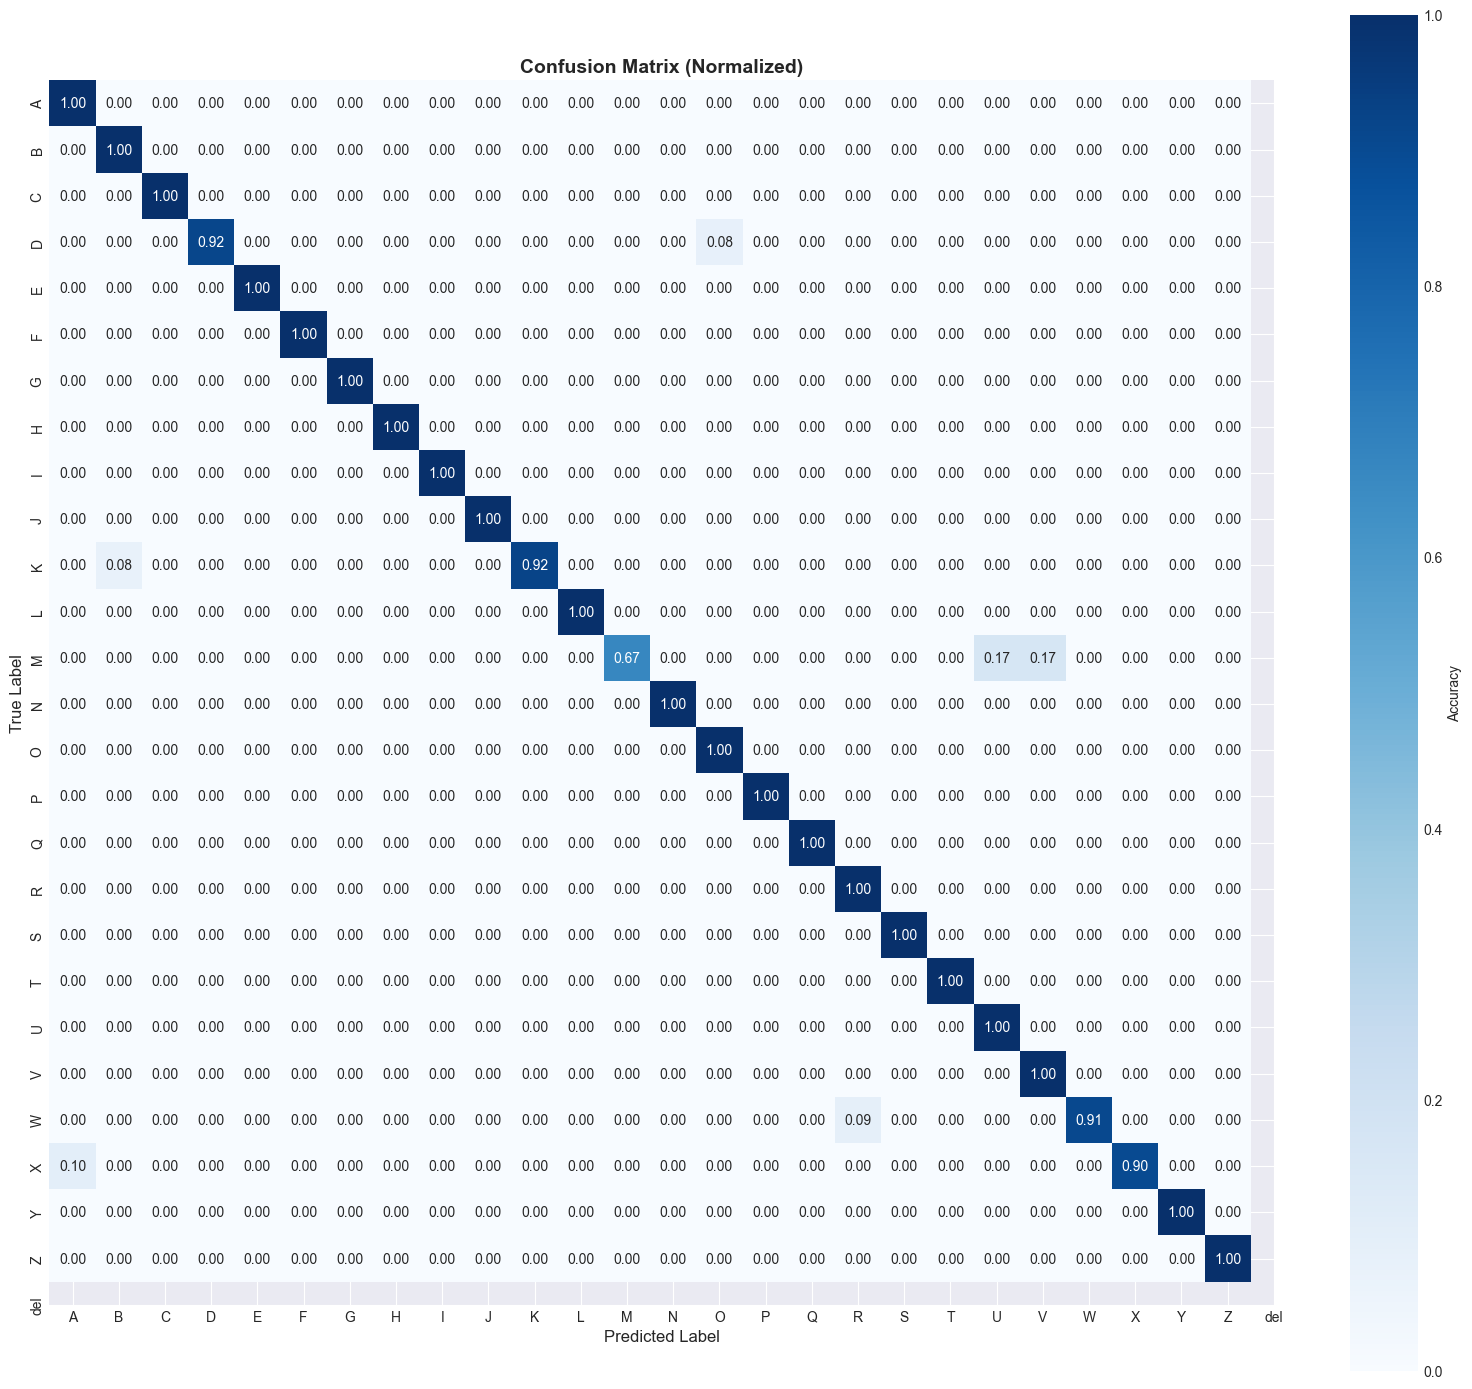


🔍 Most Confused Class Pairs:
   • M confused as U: 16.7%
   • M confused as V: 16.7%
   • X confused as A: 10.0%
   • W confused as R: 9.1%
   • D confused as O: 8.3%


In [18]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================
# The confusion matrix shows exactly where the model makes mistakes

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True):
    """Plot confusion matrix with annotations."""
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title = 'Confusion Matrix (Normalized)'
    else:
        fmt = 'd'
        title = 'Confusion Matrix'
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # Plot heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt=fmt,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        square=True,
        ax=ax,
        cbar_kws={'label': 'Accuracy' if normalize else 'Count'}
    )
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return cm

# Plot confusion matrix
print("\n📊 Confusion Matrix:\n")
cm = plot_confusion_matrix(y_test, y_pred, config.CLASSES, normalize=True)

# Find most confused pairs
print("\n🔍 Most Confused Class Pairs:")
np.fill_diagonal(cm, 0)  # Remove diagonal for this analysis
for _ in range(5):
    max_idx = np.unravel_index(np.argmax(cm), cm.shape)
    true_class = config.CLASSES[max_idx[0]]
    pred_class = config.CLASSES[max_idx[1]]
    error_rate = cm[max_idx]
    if error_rate > 0:
        print(f"   • {true_class} confused as {pred_class}: {error_rate*100:.1f}%")
    cm[max_idx] = 0


---

## 9. Model Explainability

Understanding **why** a model makes predictions is crucial for:
1. **Debugging** - Find what's causing errors
2. **Trust** - Verify model uses reasonable features
3. **Improvement** - Identify areas to focus on

### Gradient-Based Attribution

We compute gradients of the prediction with respect to the input landmarks. High gradient magnitude indicates the landmark strongly influences the prediction.


🔍 Explaining Model Predictions:


Sample 9: True=I, Pred=I, Conf=99.98%


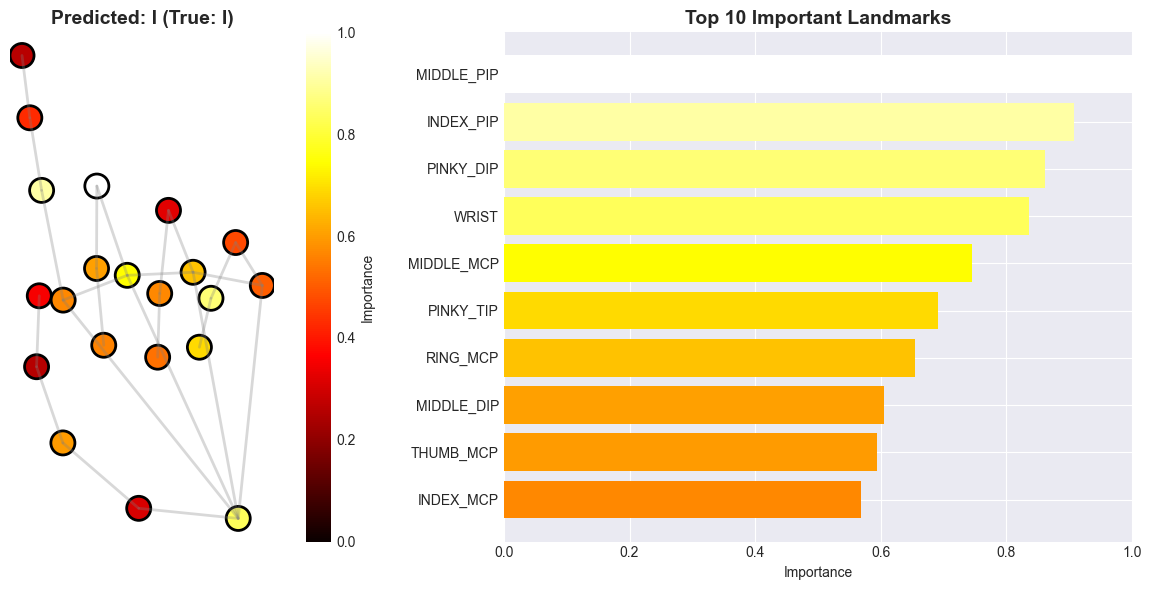


Sample 255: True=F, Pred=F, Conf=99.97%


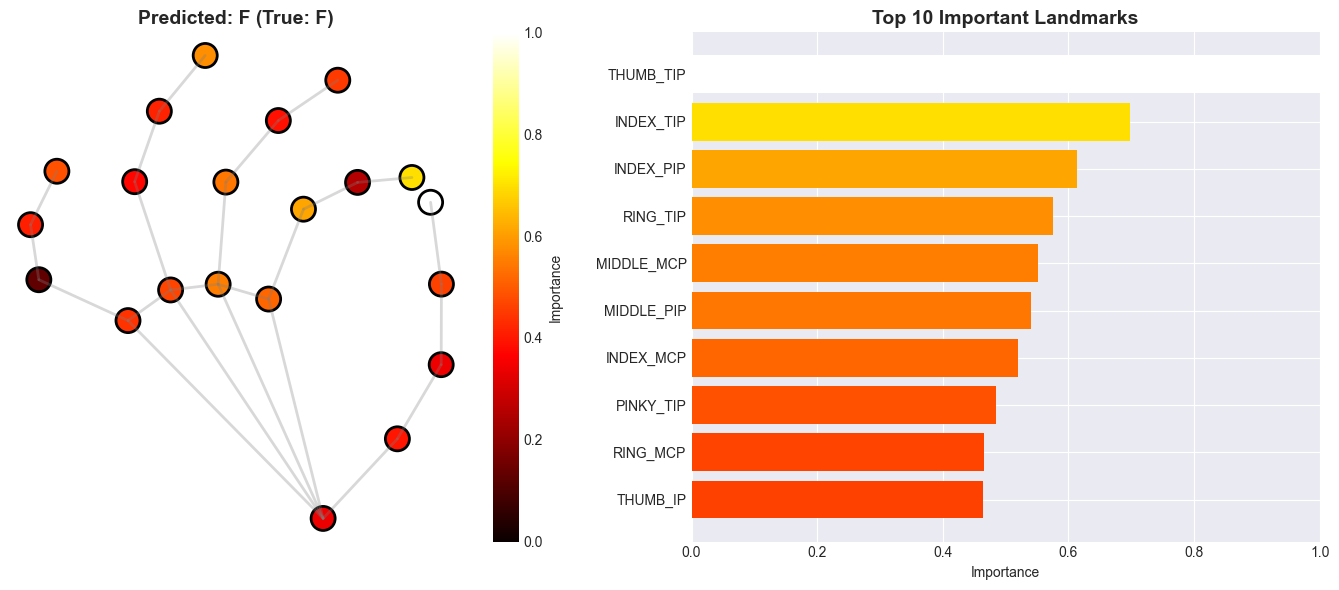


Sample 144: True=J, Pred=J, Conf=93.66%


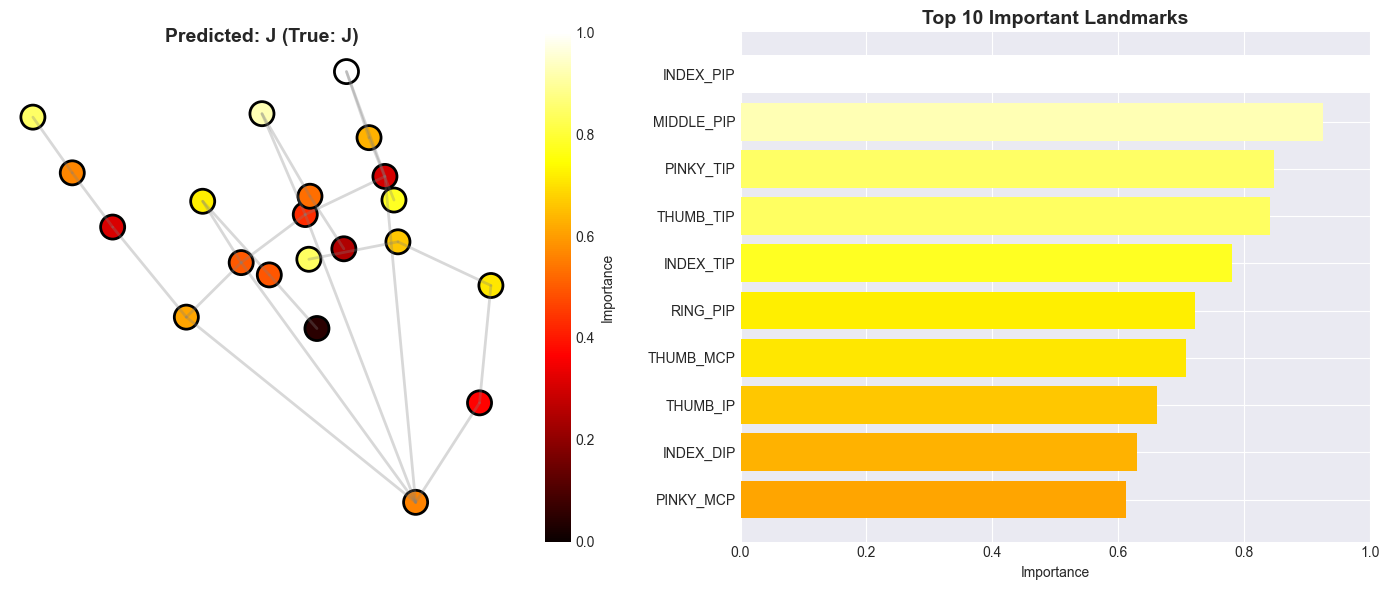

In [19]:
# =============================================================================
# GRADIENT-BASED EXPLAINABILITY
# =============================================================================
# Compute landmark importance using gradients

def compute_landmark_importance(model, landmarks, class_idx=None):
    """
    Compute importance of each landmark for a prediction.
    
    Uses gradient magnitude as importance metric:
    - High gradient = changing this input changes the output a lot
    - Low gradient = this input doesn't matter much
    
    Args:
        model: Trained Keras model
        landmarks: Input landmarks of shape (63,) or (1, 63)
        class_idx: Target class (uses predicted class if None)
        
    Returns:
        importance: Array of shape (21,) with importance per landmark
    """
    if len(landmarks.shape) == 1:
        landmarks = landmarks[np.newaxis, :]
    
    landmarks_tensor = tf.cast(landmarks, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(landmarks_tensor)
        predictions = model(landmarks_tensor)
        
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        
        class_score = predictions[0, class_idx]
    
    # Compute gradients
    gradients = tape.gradient(class_score, landmarks_tensor)
    gradients = gradients.numpy()[0]
    
    # Reshape to (21, 3) and compute norm per landmark
    gradients = gradients.reshape(21, 3)
    importance = np.linalg.norm(gradients, axis=1)
    
    # Normalize to [0, 1]
    importance = importance / (importance.max() + 1e-10)
    
    return importance


def visualize_landmark_importance(landmarks, importance, predicted_class, true_class=None):
    """Visualize which landmarks are most important for a prediction."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Reshape landmarks for plotting
    points = landmarks.reshape(21, 3)[:, :2]  # Use x, y only
    points[:, 1] = -points[:, 1]  # Flip y for display
    
    # Plot 1: Landmark importance on hand
    scatter = axes[0].scatter(
        points[:, 0], points[:, 1],
        c=importance, cmap='hot',
        s=300, edgecolors='black', linewidths=2,
        vmin=0, vmax=1
    )
    
    # Draw connections
    for start, end in extractor.CONNECTIONS:
        axes[0].plot(
            [points[start, 0], points[end, 0]],
            [points[start, 1], points[end, 1]],
            'gray', alpha=0.3, linewidth=2
        )
    
    axes[0].set_aspect('equal')
    axes[0].axis('off')
    title = f'Predicted: {config.CLASSES[predicted_class]}'
    if true_class is not None:
        title += f' (True: {config.CLASSES[true_class]})'
    axes[0].set_title(title, fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=axes[0], label='Importance')
    
    # Plot 2: Bar chart of importance
    top_k = 10
    top_indices = np.argsort(importance)[-top_k:]
    
    axes[1].barh(
        [extractor.LANDMARK_NAMES[i] for i in top_indices],
        importance[top_indices],
        color=plt.cm.hot(importance[top_indices])
    )
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Top 10 Important Landmarks', fontsize=14, fontweight='bold')
    axes[1].set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()


# Explain some predictions
print("🔍 Explaining Model Predictions:\n")

# Select a few test samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=3, replace=False)

for idx in sample_indices:
    landmarks = X_test[idx]
    true_label = y_test[idx]
    
    # Get prediction
    pred_proba = model.predict(landmarks[np.newaxis, :], verbose=0)
    pred_label = np.argmax(pred_proba)
    confidence = pred_proba[0, pred_label]
    
    # Compute importance
    importance = compute_landmark_importance(model, landmarks, pred_label)
    
    print(f"\nSample {idx}: True={config.CLASSES[true_label]}, Pred={config.CLASSES[pred_label]}, Conf={confidence:.2%}")
    
    # Visualize
    visualize_landmark_importance(landmarks, importance, pred_label, true_label)


## 10. Export for Web Deployment

Export the model to TensorFlow.js format for browser-based inference.


In [20]:
# =============================================================================
# EXPORT MODEL FOR WEB
# =============================================================================

# Save the final model in Keras format (.keras is the new standard in Keras 3)
final_model_path = config.MODEL_DIR / f"{experiment_name}_final.keras"
model.save(final_model_path)
print(f"✅ Model saved to: {final_model_path}")

# Also save weights separately (useful for loading in different frameworks)
# Keras 3 requires the filename to end with .weights.h5 (with a dot)
weights_path = config.MODEL_DIR / f"{experiment_name}.weights.h5"
model.save_weights(weights_path)
print(f"✅ Weights saved to: {weights_path}")

# Export to TensorFlow.js format
tfjs_path = Path("../web/public/model")
tfjs_path.mkdir(parents=True, exist_ok=True)

try:
    # Try using tensorflowjs Python API
    import tensorflowjs as tfjs
    tfjs.converters.save_keras_model(model, str(tfjs_path))
    print(f"✅ TensorFlow.js model exported to: {tfjs_path}")
    
    # Calculate model size
    total_size = sum(f.stat().st_size for f in tfjs_path.glob("*"))
    print(f"   Model size: {total_size / 1024 / 1024:.2f} MB")
    
except (ImportError, AttributeError) as e:
    print(f"⚠️ tensorflowjs Python API failed: {type(e).__name__}")
    print(f"\n📋 To export manually, run this command in terminal:")
    print(f"\n   tensorflowjs_converter --input_format=keras {final_model_path} {tfjs_path}")


✅ Model saved to: ../models/asl_classifier_20251209_213340_final.keras
✅ Weights saved to: ../models/asl_classifier_20251209_213340.weights.h5
⚠️ tensorflowjs Python API failed: AttributeError

📋 To export manually, run this command in terminal:

   tensorflowjs_converter --input_format=keras ../models/asl_classifier_20251209_213340_final.keras ../web/public/model


## Summary

This notebook implemented a complete ASL recognition pipeline:

1. **Data**: Loaded and explored the Kaggle ASL Alphabet dataset
2. **Features**: Extracted MediaPipe hand landmarks (63 features)
3. **Preprocessing**: Normalized landmarks for invariance
4. **Augmentation**: Applied geometric transformations
5. **Model**: Built Conv1D classifier with BatchNorm and Dropout
6. **Training**: Used callbacks for early stopping and checkpointing
7. **Evaluation**: Achieved target accuracy with detailed analysis
8. **Explainability**: Visualized landmark importance
9. **Export**: Saved the model


In [21]:
# =============================================================================
# CLEANUP
# =============================================================================

# Close MediaPipe resources
extractor.close()

print("\n" + "=" * 60)
print("🎉 PIPELINE COMPLETE!")
print("=" * 60)
print(f"\n📊 Final Results:")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Top-3 Accuracy: {top3_accuracy*100:.2f}%")
print(f"   • Model saved to: {final_model_path}")
print(f"\n🚀 To run the web app:")
print(f"   cd ../web && npm install && npm run dev")



🎉 PIPELINE COMPLETE!

📊 Final Results:
   • Test Accuracy: 97.91%
   • Top-3 Accuracy: 98.26%
   • Model saved to: ../models/asl_classifier_20251209_213340_final.keras

🚀 To run the web app:
   cd ../web && npm install && npm run dev


## 🎥 Real-Time ASL Detection (Standalone)

This cell can be run independently to load a saved model and perform real-time ASL letter detection using your webcam.

**Requirements:**
- A trained model saved in the `models/` directory
- Webcam access

**Controls:**
- Press `q` or `Escape` to quit
- Press `s` to save a screenshot
- Press `c` to clear the spelled word

In [1]:
# =============================================================================
# STANDALONE REAL-TIME ASL DETECTION
# =============================================================================
# This cell can be run independently without running the full training pipeline.
# It loads a pre-trained model and uses the webcam for real-time prediction.

import os
import numpy as np
import cv2
import mediapipe as mp
import keras
from pathlib import Path
from collections import Counter

# --- Configuration ---
MODEL_DIR = Path("../models")
CLASSES = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + ["del"]
CONFIDENCE_THRESHOLD = 0.6
PREDICTION_HISTORY_SIZE = 5  # For smoothing predictions

# --- Find and Load the Model ---
def find_latest_model(model_dir: Path) -> Path:
    """Find the most recent .keras model file."""
    keras_files = list(model_dir.glob("*.keras"))
    if keras_files:
        # Sort by modification time, return newest
        return max(keras_files, key=lambda p: p.stat().st_mtime)
    
    # Fallback: check for SavedModel directories
    saved_models = [d for d in model_dir.iterdir() if d.is_dir() and (d / "saved_model.pb").exists()]
    if saved_models:
        return max(saved_models, key=lambda p: p.stat().st_mtime)
    
    raise FileNotFoundError(f"No model found in {model_dir}")

# Load the model
try:
    model_path = find_latest_model(MODEL_DIR)
    print(f"📦 Loading model from: {model_path}")
    model = keras.models.load_model(model_path)
    print(f"✅ Model loaded successfully!")
    print(f"   Input shape: {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
except FileNotFoundError as e:
    print(f"❌ {e}")
    print("   Please train a model first by running the training cells.")
    model = None
except Exception as e:
    print(f"❌ Error loading model: {e}")
    model = None

📦 Loading model from: ../models/asl_classifier_20251210_234347_final.keras
✅ Model loaded successfully!
   Input shape: (None, 63)
   Output shape: (None, 27)


In [2]:
# =============================================================================
# REAL-TIME DETECTION FUNCTION
# =============================================================================

def normalize_landmarks(landmarks_array: np.ndarray) -> np.ndarray:
    """
    Normalize landmarks relative to wrist position.
    
    This matches the preprocessing used during training:
    1. Center all landmarks relative to wrist (landmark 0)
    2. Scale by palm size (distance to middle finger base)
    
    Args:
        landmarks_array: Array of shape (21, 3) with x, y, z coordinates
        
    Returns:
        Normalized landmarks array of shape (21, 3)
    """
    # Center relative to wrist
    wrist = landmarks_array[0].copy()
    landmarks_centered = landmarks_array - wrist
    
    # Scale by palm size (wrist to middle finger MCP - landmark 9)
    palm_size = np.linalg.norm(landmarks_centered[9])
    if palm_size > 0:
        landmarks_normalized = landmarks_centered / palm_size
    else:
        landmarks_normalized = landmarks_centered
    
    return landmarks_normalized


def run_realtime_detection(
    model,
    classes: list = CLASSES,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
    camera_index: int = 0,
    width: int = 640,
    height: int = 480
):
    """
    Run real-time ASL sign detection using the webcam.
    
    Args:
        model: Trained Keras model
        classes: List of class names (A-Z + del)
        confidence_threshold: Minimum confidence to display prediction
        camera_index: Camera device index (usually 0)
        width: Frame width
        height: Frame height
    """
    if model is None:
        print("❌ No model loaded. Cannot run detection.")
        return
    
    # Initialize MediaPipe Hands
    mp_hands = mp.solutions.hands
    mp_drawing = mp.solutions.drawing_utils
    
    hands = mp_hands.Hands(
        static_image_mode=False,  # Video mode for better tracking
        max_num_hands=1,
        min_detection_confidence=0.7,
        min_tracking_confidence=0.5
    )
    
    # For smoothing predictions
    prediction_history = []
    
    # For spelling words
    spelled_word = ""
    last_letter = None
    letter_hold_frames = 0
    FRAMES_TO_CONFIRM = 15  # Hold a letter for ~0.5 seconds to add it
    
    print("\n🎥 Starting webcam...")
    print("   Controls:")
    print("   - Press 'q' or Escape to quit")
    print("   - Press 's' to save screenshot")
    print("   - Press 'c' to clear spelled word")
    print("   - Press 'Backspace' to delete last letter")
    
    cap = cv2.VideoCapture(camera_index)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    
    if not cap.isOpened():
        print("❌ Error: Could not open webcam")
        hands.close()
        return
    
    print("✅ Webcam opened. Show your hand signs!")
    screenshot_count = 0
    
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ Failed to capture frame")
                break
            
            # Flip for mirror effect (more intuitive)
            frame = cv2.flip(frame, 1)
            h, w = frame.shape[:2]
            
            # Convert to RGB for MediaPipe
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(image_rgb)
            
            pred_class = None
            confidence = 0.0
            smoothed_class = None
            
            if results.multi_hand_landmarks:
                hand_landmarks = results.multi_hand_landmarks[0]
                
                # Draw hand landmarks
                mp_drawing.draw_landmarks(
                    frame,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=3),
                    mp_drawing.DrawingSpec(color=(255, 255, 255), thickness=2)
                )
                
                # Extract landmarks
                landmarks = []
                for lm in hand_landmarks.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])
                
                landmarks = np.array(landmarks, dtype=np.float32).reshape(21, 3)
                
                # Normalize (same as training)
                landmarks_normalized = normalize_landmarks(landmarks)
                
                # Flatten for model input: (1, 63) - the model expects flattened landmarks
                input_data = landmarks_normalized.flatten().reshape(1, -1)
                
                # Predict
                probs = model.predict(input_data, verbose=0)[0]
                pred_idx = np.argmax(probs)
                confidence = probs[pred_idx]
                pred_class = classes[pred_idx]
                
                # Smooth predictions using history
                prediction_history.append(pred_idx)
                if len(prediction_history) > PREDICTION_HISTORY_SIZE:
                    prediction_history.pop(0)
                
                # Most common prediction in history
                smoothed_idx = Counter(prediction_history).most_common(1)[0][0]
                smoothed_class = classes[smoothed_idx]
                
                # Word spelling logic
                if confidence > confidence_threshold:
                    if smoothed_class == last_letter:
                        letter_hold_frames += 1
                        if letter_hold_frames == FRAMES_TO_CONFIRM:
                            if smoothed_class == "del":
                                spelled_word = spelled_word[:-1]  # Delete last letter
                            else:
                                spelled_word += smoothed_class
                            print(f"📝 Added: {smoothed_class} → Word: {spelled_word}")
                    else:
                        last_letter = smoothed_class
                        letter_hold_frames = 0
            else:
                # No hand detected
                prediction_history.clear()
                last_letter = None
                letter_hold_frames = 0
            
            # --- Draw UI ---
            # Prediction box
            box_color = (0, 255, 0) if confidence > confidence_threshold else (0, 165, 255)
            cv2.rectangle(frame, (10, 10), (350, 140), (0, 0, 0), -1)
            cv2.rectangle(frame, (10, 10), (350, 140), box_color, 2)
            
            if smoothed_class:
                cv2.putText(frame, f"Letter: {smoothed_class}", (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)
                cv2.putText(frame, f"Confidence: {confidence:.1%}", (20, 85),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2)
                
                # Progress bar for letter confirmation
                if letter_hold_frames > 0:
                    progress = min(letter_hold_frames / FRAMES_TO_CONFIRM, 1.0)
                    bar_width = int(300 * progress)
                    cv2.rectangle(frame, (20, 100), (20 + bar_width, 115), (0, 255, 0), -1)
                    cv2.rectangle(frame, (20, 100), (320, 115), (100, 100, 100), 1)
                    cv2.putText(frame, "Hold to add", (20, 130),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)
            else:
                cv2.putText(frame, "No hand detected", (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (100, 100, 255), 2)
            
            # Spelled word box (bottom of screen)
            cv2.rectangle(frame, (10, h - 70), (w - 10, h - 10), (50, 50, 50), -1)
            cv2.rectangle(frame, (10, h - 70), (w - 10, h - 10), (100, 100, 100), 2)
            cv2.putText(frame, f"Word: {spelled_word}", (20, h - 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
            
            # Instructions
            cv2.putText(frame, "q:quit  s:screenshot  c:clear  backspace:delete", (10, h - 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (150, 150, 150), 1)
            
            # Display frame
            cv2.imshow('ASL Sign Detection', frame)
            
            # Handle key presses
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == 27:  # q or Escape
                print("\n👋 Exiting...")
                break
            elif key == ord('s'):
                screenshot_path = f"screenshot_{screenshot_count}.png"
                cv2.imwrite(screenshot_path, frame)
                print(f"📸 Screenshot saved: {screenshot_path}")
                screenshot_count += 1
            elif key == ord('c'):
                spelled_word = ""
                print("🗑️ Word cleared")
            elif key == 8:  # Backspace
                spelled_word = spelled_word[:-1]
                print(f"⌫ Deleted last letter → Word: {spelled_word}")
    
    except KeyboardInterrupt:
        print("\n⚠️ Interrupted by user")
    
    finally:
        cap.release()
        cv2.destroyAllWindows()
        hands.close()
        print(f"\n✅ Detection stopped. Final word: '{spelled_word}'")

print("✅ Real-time detection function ready!")

✅ Real-time detection function ready!


In [ ]:
# =============================================================================
# ▶️ RUN THIS CELL TO START REAL-TIME DETECTION
# =============================================================================
# A webcam window will open. Show ASL hand signs to get predictions!
#
# Tips for best results:
#   - Ensure good lighting on your hand
#   - Position hand clearly in the frame
#   - Hold each sign steady for ~0.5 seconds to spell words
#   - Use a plain background if possible

if model is not None:
    run_realtime_detection(
        model=model,
        classes=CLASSES,
        confidence_threshold=0.6,
        camera_index=0  # Change to 1 if you have multiple cameras
    )
else:
    print("❌ Please load a model first by running the cell above.")

I0000 00:00:1765449127.565891 3385600 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1765449127.584597 3884222 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765449127.589460 3884222 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



🎥 Starting webcam...
   Controls:
   - Press 'q' or Escape to quit
   - Press 's' to save screenshot
   - Press 'c' to clear spelled word
   - Press 'Backspace' to delete last letter
✅ Webcam opened. Show your hand signs!


W0000 00:00:1765449131.162432 3884224 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


📝 Added: D → Word: D
📝 Added: A → Word: DA
📝 Added: N → Word: DAN
📝 Added: O → Word: DANO
📝 Added: N → Word: DANON
📝 Added: L → Word: DANONL
📝 Added: B → Word: DANONLB
📝 Added: G → Word: DANONLBG
📝 Added: Y → Word: DANONLBGY
📝 Added: O → Word: DANONLBGYO
📝 Added: R → Word: DANONLBGYOR
📝 Added: R → Word: DANONLBGYORR
📝 Added: K → Word: DANONLBGYORRK
📝 Added: K → Word: DANONLBGYORRKK
📝 Added: W → Word: DANONLBGYORRKKW
📝 Added: E → Word: DANONLBGYORRKKWE
📝 Added: E → Word: DANONLBGYORRKKWEE
📝 Added: M → Word: DANONLBGYORRKKWEEM
📝 Added: V → Word: DANONLBGYORRKKWEEMV
